### **Step 1: Understand Project Requirements**

This is a crucial step to set the foundation for the project. Breaking it down into actionable points ensures clarity and focus:

---

#### **1.1 Define Objectives**
- Identify the purpose of the project:
  - Analyze customer behavior using key metrics like `Customer_Satisfaction` and `Return_Status`.
  - Predict `Total_Price` for forecasting revenue.
  - Classify `Return_Status` to understand patterns in product returns.

---

#### **1.2 Determine Key Metrics**
- For **Regression Models**:
  - Use metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE):
    - MAE: <img src="https://latex.codecogs.com/svg.image?&space;MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|" title="MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|" />
    - RMSE: <img src="https://latex.codecogs.com/svg.image?&space;RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}" title="RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}" />
- For **Classification Models**:
  - Evaluate accuracy, precision, recall, and F1-score:
    - Accuracy: <img src="https://latex.codecogs.com/svg.image?&space;Accuracy=\frac{TP+TN}{TP+TN+FP+FN}" title="Accuracy=\frac{TP+TN}{TP+TN+FP+FN}" />

---

#### **1.3 Understand Dataset Scope**
- Dataset Highlights:
  - 50,000 rows, 20 columns.
  - Features include transaction details (`Transaction_ID`, `Date`), customer demographics (`Customer_Age`, `Customer_Gender`), and financial data (`Product_Price`, `Total_Price`).
  - Synthetic dataset—safe for public use.
- Anticipated Challenges:
  - Missing values in columns like `Date`, `Product_ID`.
  - Outliers in numerical fields such as `Product_Price`.

---

#### **1.4 Identify Tasks**
- **Data Preprocessing**:
  - Handle missing values.
  - Encode categorical variables (e.g., `Payment_Method`).
- **Feature Engineering**:
  - Example: Calculate `Discounted_Price`:
    - Formula: <img src="https://latex.codecogs.com/svg.image?&space;Discounted\_Price=Product\_Price*(1-\frac{Discount}{100})" title="Discounted\_Price=Product\_Price*(1-\frac{Discount}{100})" />
- **EDA**:
  - Explore trends in `Profit_Margin (%)` across different `Store_Location`.
  - Analyze seasonality in transactions using `Date`.

---

#### **1.5 Define Deliverables**
- **Visualization Dashboard**:
  - Visualize trends in revenue and product performance.
- **Predictive Models**:
  - Regression: Predict `Total_Price`.
  - Classification: Identify patterns in `Return_Status`.
- **Insights**:
  - Recommendations for business strategies based on analysis.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
import joblib
from sklearn.impute import SimpleImputer


datasets = '/kaggle/input/customer-data-1/Custom_Business_Data_1.csv'
business_data = pd.read_csv(datasets)

In [73]:
# 1. Understand Dataset Scope
# Display basic information about the dataset
print("Dataset Information:")
print(business_data.info())

print("\nFirst 5 rows of the dataset:")
print(business_data.head())

# Summary statistics
print("\nSummary Statistics:")
print(business_data.describe())

# Check for missing values
missing_values = business_data.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         50000 non-null  object 
 1   Date                   49829 non-null  object 
 2   Customer_ID            50000 non-null  object 
 3   Customer_Age           50000 non-null  int64  
 4   Customer_Gender        49973 non-null  object 
 5   Product_ID             49969 non-null  object 
 6   Product_Category       50000 non-null  object 
 7   Product_Price          49954 non-null  float64
 8   Quantity               49991 non-null  float64
 9   Discount (%)           50000 non-null  int64  
 10  Payment_Method         49983 non-null  object 
 11  Store_Location         50000 non-null  object 
 12  Employee_ID            49946 non-null  object 
 13  Sales_Channel          50000 non-null  object 
 14  Advertising_Cost       49982 non-

In [74]:
# 2. Key Insights about Dataset
# Number of unique values in each column
unique_values = business_data.nunique()
print("\nUnique Values in Each Column:")
print(unique_values)


Unique Values in Each Column:
Transaction_ID           50000
Date                      1461
Customer_ID               8972
Customer_Age                52
Customer_Gender              2
Product_ID                 500
Product_Category             5
Product_Price            31518
Quantity                    19
Discount (%)                50
Payment_Method               3
Store_Location               5
Employee_ID                900
Sales_Channel                2
Advertising_Cost         39307
Profit_Margin (%)           25
Return_Status                2
Customer_Satisfaction        5
Annual_Income            49862
Total_Price              46961
dtype: int64


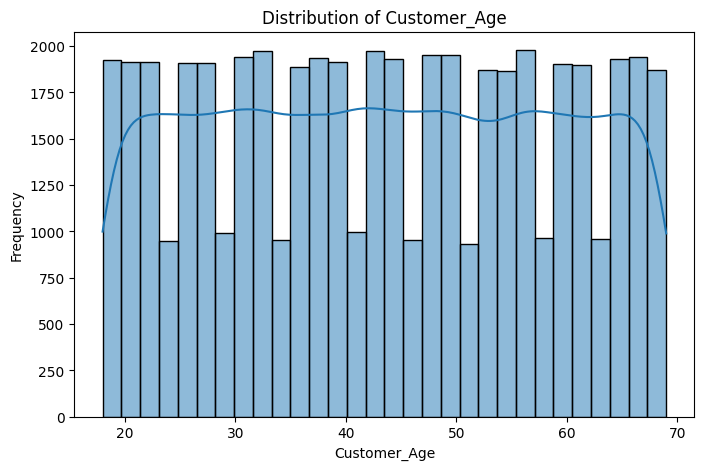

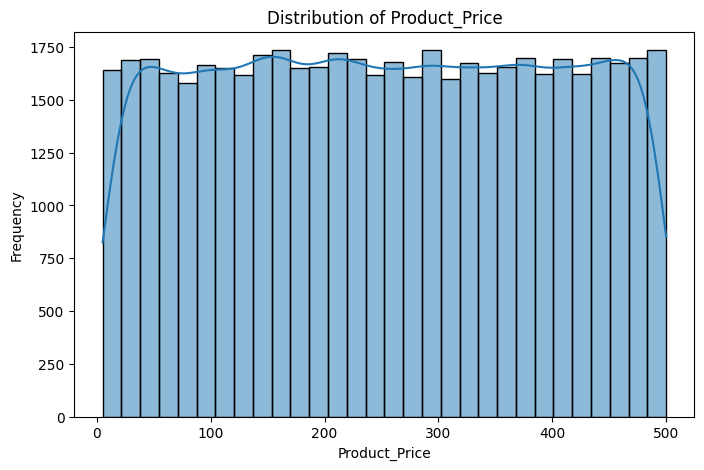

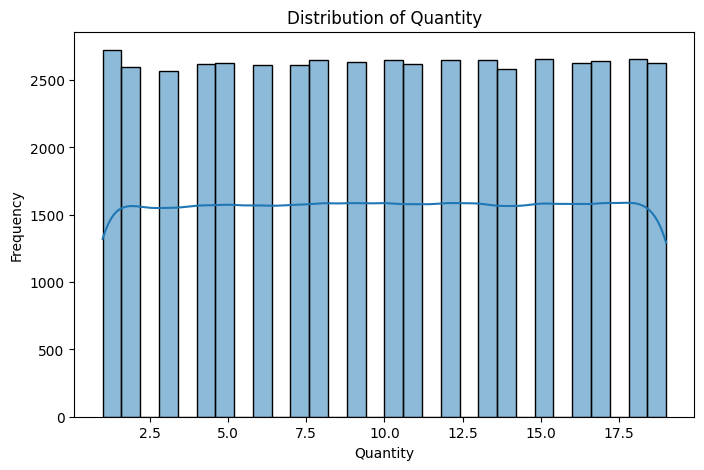

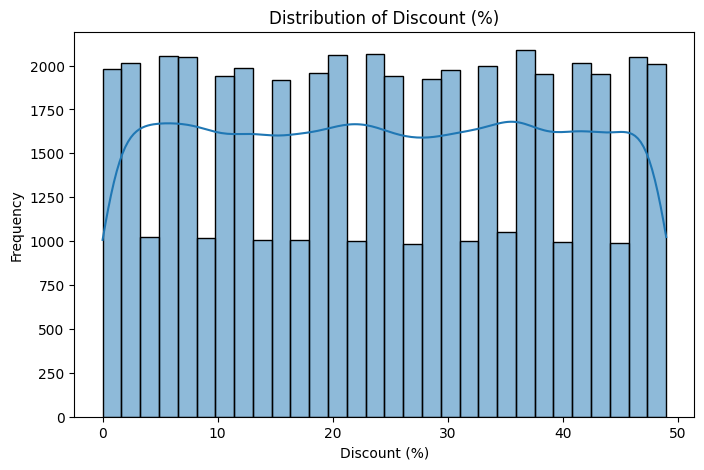

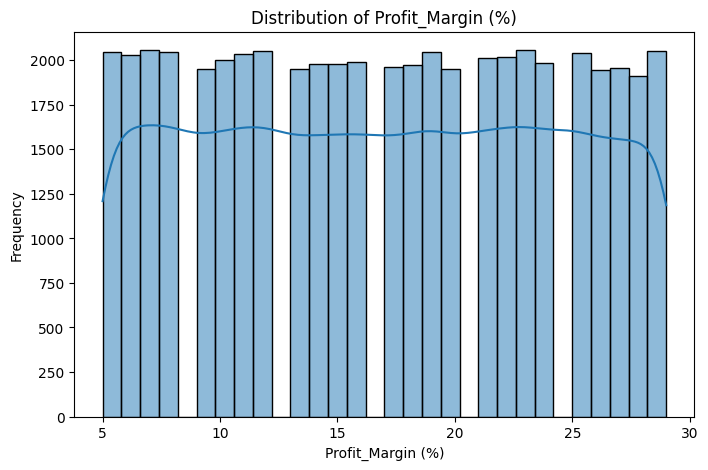

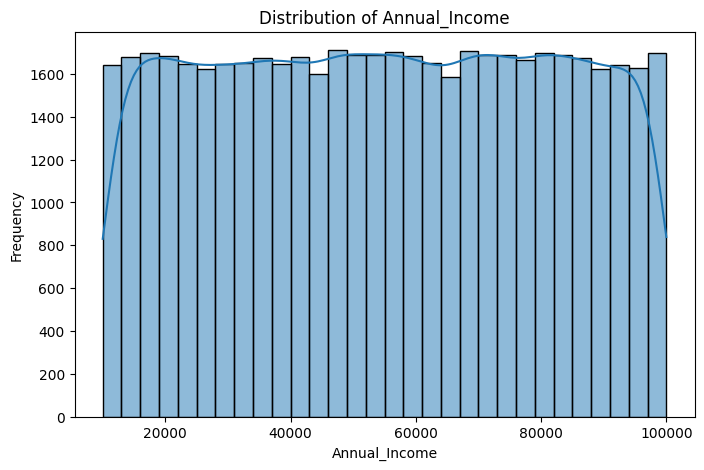

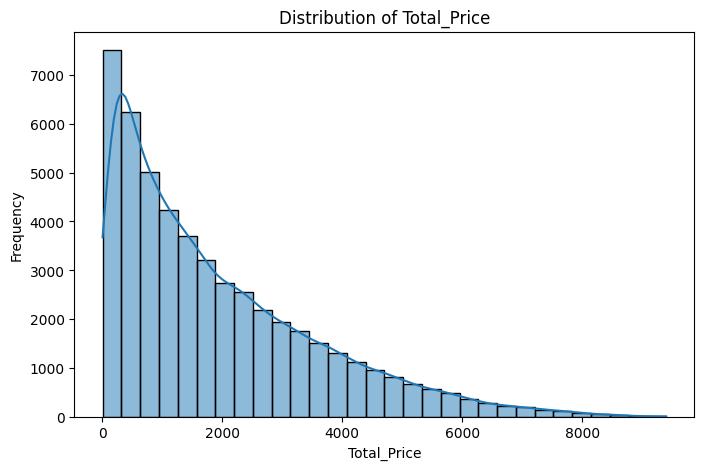

In [75]:
# 3. Exploratory Data Analysis (EDA)
# Distribution of numerical features
numerical_features = ['Customer_Age', 'Product_Price', 'Quantity', 'Discount (%)', 'Profit_Margin (%)', 'Annual_Income', 'Total_Price']
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(business_data[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()



First 5 Rows with 'Discounted_Price':
   Product_Price  Discount (%)  Discounted_Price
0          97.92            13           85.1904
1         256.51            42          148.7758
2         344.73            10          310.2570
3         381.69             1          377.8731
4         448.53             5          426.1035


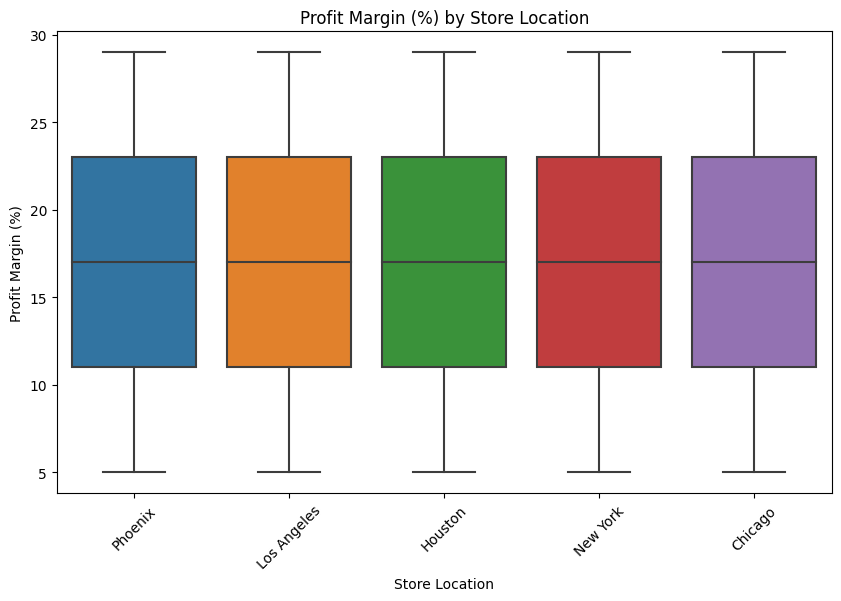

In [76]:

# 4. Initial Feature Engineering Example
# Calculate Discounted Price
business_data['Discounted_Price'] = business_data['Product_Price'] * (1 - (business_data['Discount (%)'] / 100))

# Display the first few rows with the new column
print("\nFirst 5 Rows with 'Discounted_Price':")
print(business_data[['Product_Price', 'Discount (%)', 'Discounted_Price']].head())

# 5. Trends in Profit_Margin (%) by Store_Location
plt.figure(figsize=(10, 6))
sns.boxplot(data=business_data, x='Store_Location', y='Profit_Margin (%)')
plt.title('Profit Margin (%) by Store Location')
plt.xlabel('Store Location')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)
plt.show()


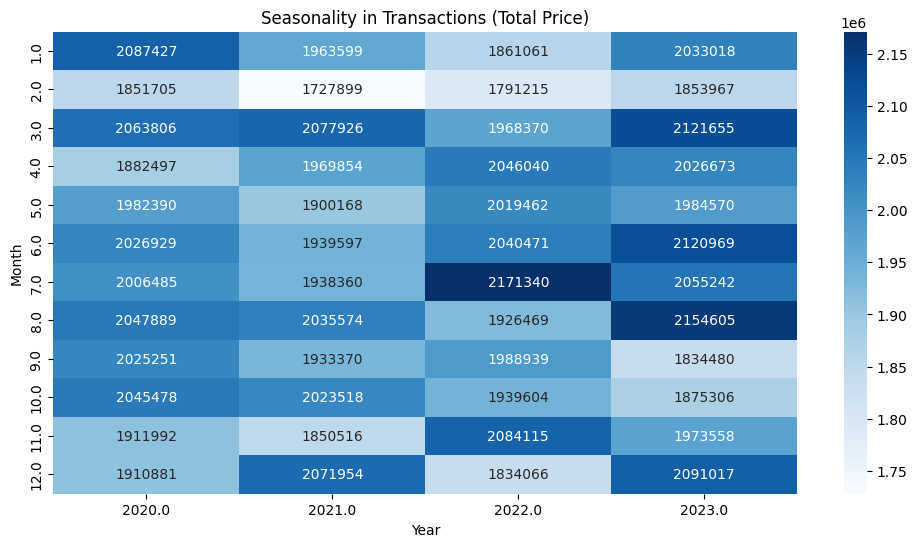


Processed dataset saved as 'Processed_Business_Data.csv'


In [77]:
# 6. Seasonality Analysis in Transactions
# Extract year and month from the Date column
business_data['Date'] = pd.to_datetime(business_data['Date'], errors='coerce')
business_data['Year'] = business_data['Date'].dt.year
business_data['Month'] = business_data['Date'].dt.month

# Group data by Year and Month
seasonality = business_data.groupby(['Year', 'Month'])['Total_Price'].sum().reset_index()
seasonality_pivot = seasonality.pivot(index='Month', columns='Year', values='Total_Price')

# Plot the seasonality trend
plt.figure(figsize=(12, 6))
sns.heatmap(seasonality_pivot, cmap='Blues', annot=True, fmt=".0f")
plt.title('Seasonality in Transactions (Total Price)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

# Save the processed dataset for future steps
business_data.to_csv('Processed_Business_Data.csv', index=False)
print("\nProcessed dataset saved as 'Processed_Business_Data.csv'")


### **Step 2: Data Preprocessing**

Data preprocessing is essential to clean and prepare the dataset for analysis and modeling. Below are the key steps and subpoints:

---

#### **2.1 Handle Missing Values**
- Identify columns with missing data.
- Use appropriate strategies based on data types:
  1. **Numerical Columns**:
     - Impute missing values with the mean or median:
       <img src="https://latex.codecogs.com/svg.image?&space;x_{\text{mean}}=\frac{1}{n}\sum_{i=1}^{n}x_i" title="x_{\text{mean}}=\frac{1}{n}\sum_{i=1}^{n}x_i" />
       <img src="https://latex.codecogs.com/svg.image?&space;x_{\text{median}}=\text{middle&space;value}" title="x_{\text{median}}=\text{middle value}" />
  2. **Categorical Columns**:
     - Impute with the mode (most frequent category) or create an "Unknown" category.

---

#### **2.2 Handle Outliers**
- Detect and treat outliers using:
  - **Z-Score Method**:
    <img src="https://latex.codecogs.com/svg.image?&space;z_i=\frac{x_i-\mu}{\sigma}" title="z_i=\frac{x_i-\mu}{\sigma}" />
    - If <img src="https://latex.codecogs.com/svg.image?&space;|z_i|>3" title="|z_i|>3" />, consider the value an outlier.
  - **IQR Method**:
    <img src="https://latex.codecogs.com/svg.image?&space;IQR=Q_3-Q_1" title="IQR=Q_3-Q_1" />, where:
    - <img src="https://latex.codecogs.com/svg.image?&space;Q_1=\text{25th&space;percentile}" title="Q_1=\text{25th percentile}" />
    - <img src="https://latex.codecogs.com/svg.image?&space;Q_3=\text{75th&space;percentile}" title="Q_3=\text{75th percentile}" />
    - Outlier thresholds: 
      - Lower Bound: <img src="https://latex.codecogs.com/svg.image?&space;Q_1-1.5\times&space;IQR" title="Q_1-1.5\times IQR" />
      - Upper Bound: <img src="https://latex.codecogs.com/svg.image?&space;Q_3+1.5\times&space;IQR" title="Q_3+1.5\times IQR" />

---

#### **2.3 Encode Categorical Data**
- Convert categorical variables into numerical values using:
  - **One-Hot Encoding**:
    - For a category <img src="https://latex.codecogs.com/svg.image?&space;x" title="x" /> with 3 levels (`A`, `B`, `C`), create binary columns:
      - `x_A`, `x_B`, `x_C` where:
        - `x_A = 1` if `x` is `A`; otherwise `0`.
  - **Label Encoding**:
    - Assign integers: `A = 1`, `B = 2`, `C = 3`.

---

#### **2.4 Normalize Numerical Features**
- Scale numerical data to ensure consistent ranges:
  - **Min-Max Scaling**:
    <img src="https://latex.codecogs.com/svg.image?&space;x'=\frac{x-\text{min}(x)}{\text{max}(x)-\text{min}(x)}" title="x'=\frac{x-\text{min}(x)}{\text{max}(x)-\text{min}(x)}" />
  - **Standardization**:
    <img src="https://latex.codecogs.com/svg.image?&space;x'=\frac{x-\mu}{\sigma}" title="x'=\frac{x-\mu}{\sigma}" />

---

#### **2.5 Handle Duplicate Records**
- Check for duplicates:
  - Use `duplicated()` to identify them.
- Remove duplicates to maintain data integrity.

---

#### **2.6 Save Preprocessed Data**
- Export the cleaned dataset for further analysis:
  - Save the preprocessed file using `to_csv()`.


In [78]:
# 1. Handle Missing Values
# Impute missing numerical columns with mean
numerical_columns = ['Product_Price', 'Quantity', 'Profit_Margin (%)', 'Advertising_Cost', 'Annual_Income']
for column in numerical_columns:
    business_data[column].fillna(business_data[column].mean(), inplace=True)

# Impute missing categorical columns with mode
categorical_columns = ['Customer_Gender', 'Product_ID', 'Payment_Method', 'Employee_ID']
for column in categorical_columns:
    business_data[column].fillna(business_data[column].mode()[0], inplace=True)

# Impute missing dates with the most frequent date
business_data['Date'].fillna(business_data['Date'].mode()[0], inplace=True)


In [79]:
# 2. Handle Outliers
# Using IQR method for outlier detection
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), np.nan, df[column])
    return df

for column in numerical_columns:
    business_data = remove_outliers(business_data, column)

# Fill any remaining outliers with the mean
for column in numerical_columns:
    business_data[column].fillna(business_data[column].mean(), inplace=True)


In [80]:
# 3. Encode Categorical Data
# One-Hot Encoding for categorical features with a few unique values
business_data = pd.get_dummies(business_data, columns=['Customer_Gender', 'Product_Category', 'Payment_Method', 'Sales_Channel'], drop_first=True)


In [81]:
# 4. Normalize Numerical Features
# Min-Max Scaling for numerical columns
scaler = MinMaxScaler()
business_data[numerical_columns] = scaler.fit_transform(business_data[numerical_columns])


In [82]:
# 5. Handle Duplicate Records
# Check for duplicates
duplicates = business_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates
business_data.drop_duplicates(inplace=True)


Number of duplicate rows: 0


In [83]:
# 6. Save Preprocessed Data
# Export the cleaned dataset
processed_file_path = 'Preprocessed_Business_Data.csv'
business_data.to_csv(processed_file_path, index=False)
print(f"Preprocessed dataset saved as '{processed_file_path}'")

# Display basic information after preprocessing
print("\nPreprocessed Dataset Info:")
print(business_data.info())

print("\nFirst 5 Rows of Preprocessed Data:")
print(business_data.head())


Preprocessed dataset saved as 'Preprocessed_Business_Data.csv'

Preprocessed Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Transaction_ID                50000 non-null  object        
 1   Date                          50000 non-null  datetime64[ns]
 2   Customer_ID                   50000 non-null  object        
 3   Customer_Age                  50000 non-null  int64         
 4   Product_ID                    50000 non-null  object        
 5   Product_Price                 50000 non-null  float64       
 6   Quantity                      50000 non-null  float64       
 7   Discount (%)                  50000 non-null  int64         
 8   Store_Location                50000 non-null  object        
 9   Employee_ID                   50000 non-null  object        
 10  Adv

### **Step 3: Exploratory Data Analysis (EDA)**

Exploratory Data Analysis involves investigating the dataset to uncover patterns, trends, and relationships. It sets the stage for feature selection and modeling.

---

#### **3.1 Understand the Distribution of Numerical Features**
- Analyze the distribution of numerical features to understand their spread, skewness, and potential outliers.
  - Example: For a numerical column <img src="https://latex.codecogs.com/svg.image?&space;x" title="x" />, compute:
    - Mean: <img src="https://latex.codecogs.com/svg.image?&space;\mu=\frac{1}{n}\sum_{i=1}^{n}x_i" title="\mu=\frac{1}{n}\sum_{i=1}^{n}x_i" />
    - Variance: <img src="https://latex.codecogs.com/svg.image?&space;\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2" title="\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2" />
    - Standard Deviation: <img src="https://latex.codecogs.com/svg.image?&space;\sigma=\sqrt{\sigma^2}" title="\sigma=\sqrt{\sigma^2}" />

---

#### **3.2 Analyze Relationships Between Features**
- Use correlation analysis to measure the linear relationship between two numerical features:
  - Correlation Coefficient: <img src="https://latex.codecogs.com/svg.image?&space;r=\frac{\sum_{i=1}^{n}(x_i-\mu_x)(y_i-\mu_y)}{\sqrt{\sum_{i=1}^{n}(x_i-\mu_x)^2}\sqrt{\sum_{i=1}^{n}(y_i-\mu_y)^2}}" title="r=\frac{\sum_{i=1}^{n}(x_i-\mu_x)(y_i-\mu_y)}{\sqrt{\sum_{i=1}^{n}(x_i-\mu_x)^2}\sqrt{\sum_{i=1}^{n}(y_i-\mu_y)^2}}" />
    - Range: <img src="https://latex.codecogs.com/svg.image?&space;-1\leq&space;r\leq&space;1" title="-1\leq r\leq 1" />.
    - Interpretations:
      - <img src="https://latex.codecogs.com/svg.image?&space;r>0" title="r>0" />: Positive correlation.
      - <img src="https://latex.codecogs.com/svg.image?&space;r<0" title="r<0" />: Negative correlation.
      - <img src="https://latex.codecogs.com/svg.image?&space;r=0" title="r=0" />: No correlation.

---

#### **3.3 Visualize Trends in Key Features**
- **Time-Based Analysis**:
  - Group by `Date` to analyze trends in `Total_Price`:
    <img src="https://latex.codecogs.com/svg.image?&space;T(t)=\sum_{i=1}^{n}\text{Total\_Price}_i\text{,&space;for&space;each&space;}t" title="T(t)=\sum_{i=1}^{n}\text{Total\_Price}_i\text{, for each }t" />
- **Category-Based Analysis**:
  - Compute aggregated metrics like mean, median, and sum for features grouped by categories (e.g., `Product_Category`).

---

#### **3.4 Analyze Profitability**
- Calculate total profitability by store location:
  - Total Profit:
    <img src="https://latex.codecogs.com/svg.image?&space;P=\sum_{i=1}^{n}(\text{Total\_Price}_i-\text{Product\_Price}_i\cdot\text{Quantity}_i)" title="P=\sum_{i=1}^{n}(\text{Total\_Price}_i-\text{Product\_Price}_i\cdot\text{Quantity}_i)" />
- Visualize profit margins for each store.

---

#### **3.5 Analyze Customer Behavior**
- Segment customers based on annual income and satisfaction levels:
  - Mean Annual Income by Satisfaction Level:
    <img src="https://latex.codecogs.com/svg.image?&space;\mu_\text{Income\_Satisfaction}=\frac{\sum_{i=1}^{n}\text{Annual\_Income}_i\cdot\text{Satisfaction}_i}{\sum_{i=1}^{n}\text{Satisfaction}_i}" title="\mu_\text{Income\_Satisfaction}=\frac{\sum_{i=1}^{n}\text{Annual\_Income}_i\cdot\text{Satisfaction}_i}{\sum_{i=1}^{n}\text{Satisfaction}_i}" />

---

#### **3.6 Examine Return Status**
- Analyze patterns in product returns (`Return_Status`):
  - Return Rate:
    <img src="https://latex.codecogs.com/svg.image?&space;\text{Return\_Rate}=\frac{\text{Total\_Returns}}{\text{Total\_Transactions}}" title="\text{Return\_Rate}=\frac{\text{Total\_Returns}}{\text{Total\_Transactions}}" />

---

#### **3.7 Summarize Insights**
- Summarize key findings from visualizations and statistical analyses.
- Prepare actionable insights for feature selection.

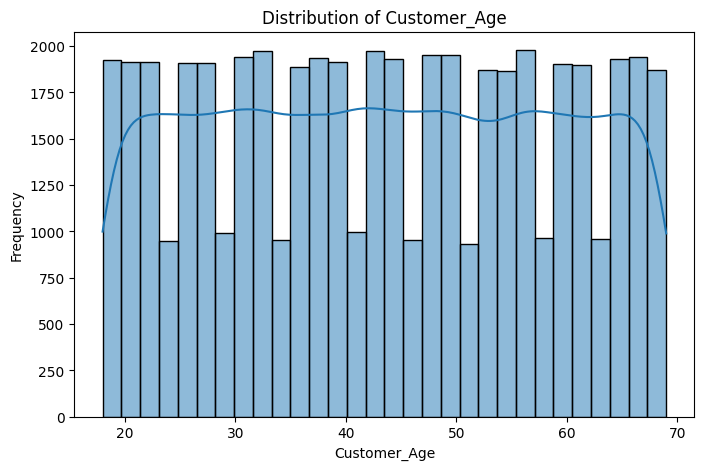

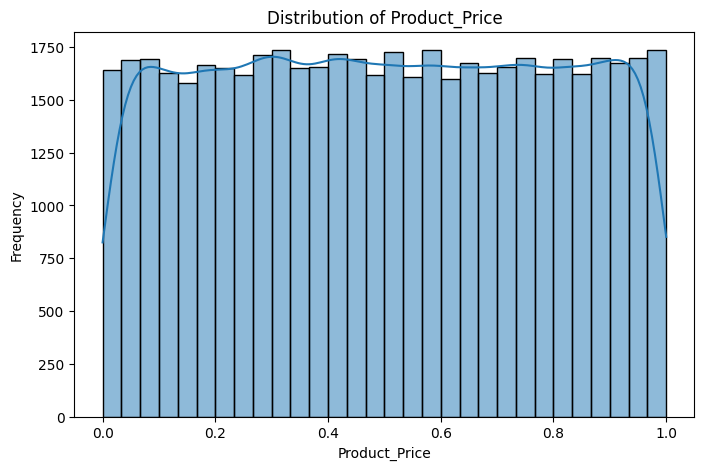

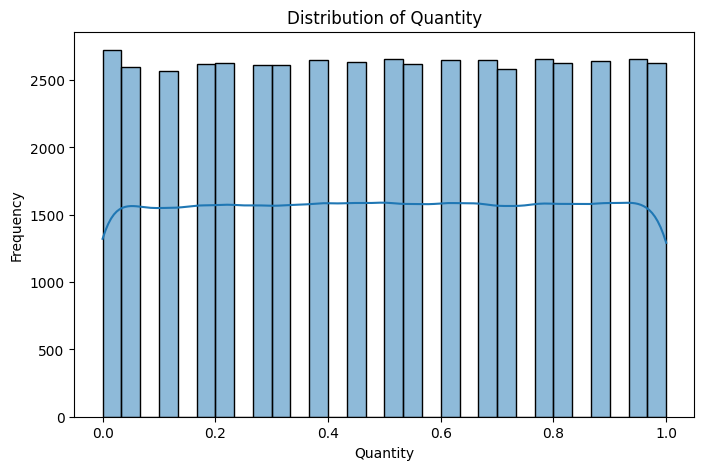

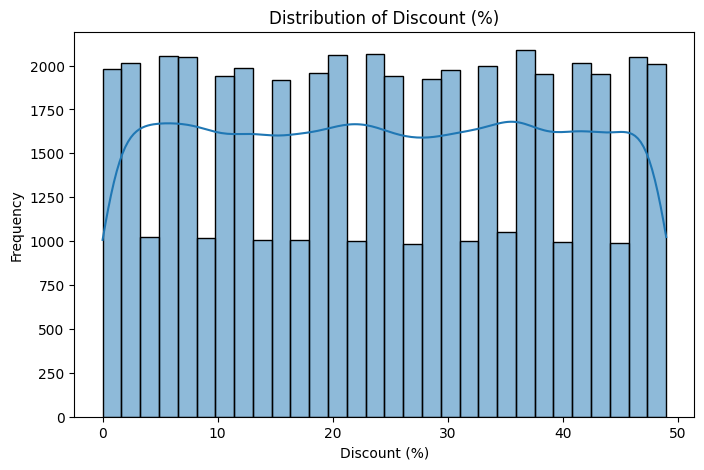

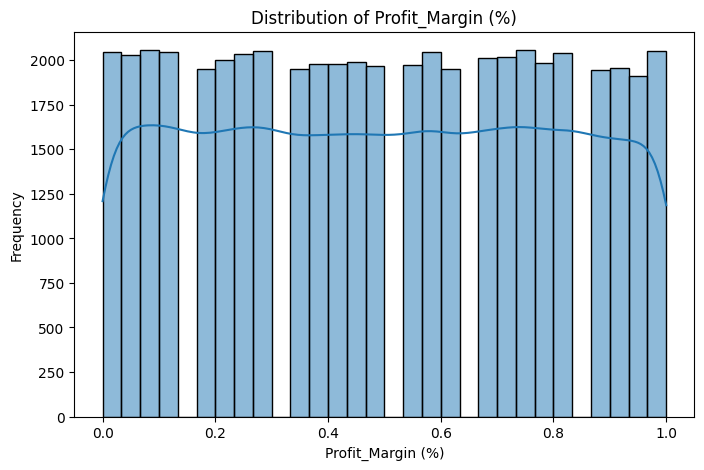

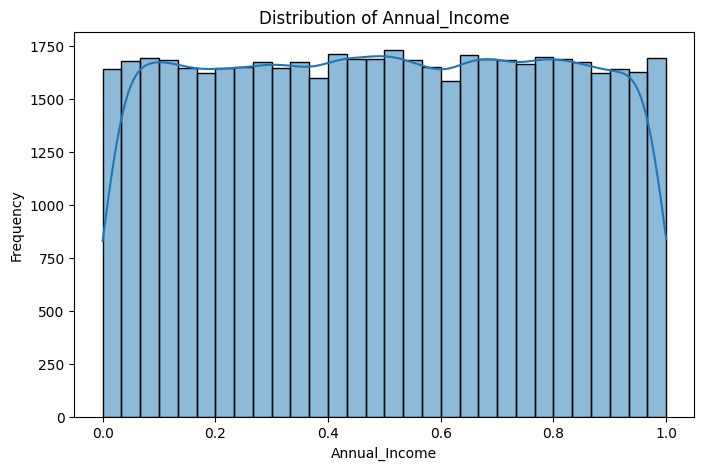

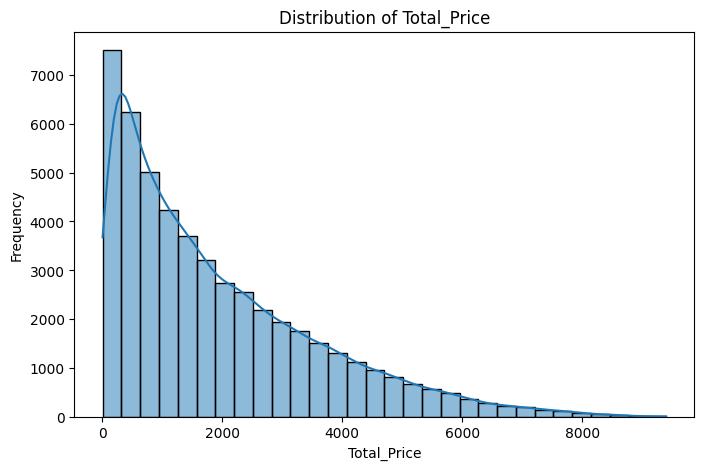

In [84]:
# 1. Understand the Distribution of Numerical Features
numerical_columns = ['Customer_Age', 'Product_Price', 'Quantity', 'Discount (%)', 
                     'Profit_Margin (%)', 'Annual_Income', 'Total_Price']

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(business_data[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


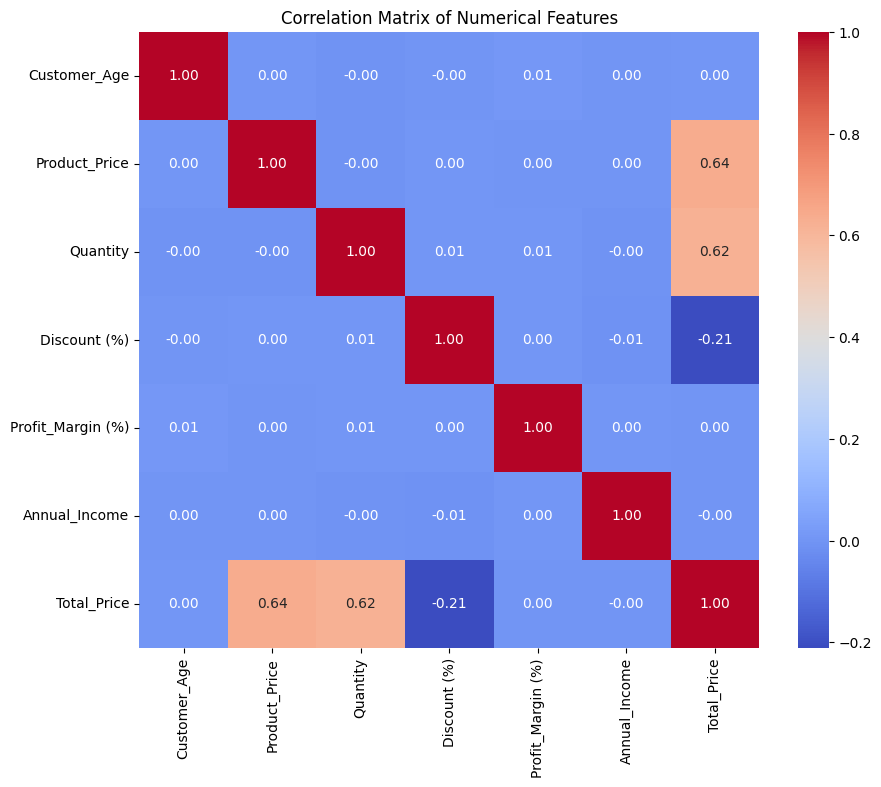

In [85]:
# 2. Analyze Relationships Between Features
# Compute and visualize the correlation matrix
correlation_matrix = business_data[numerical_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

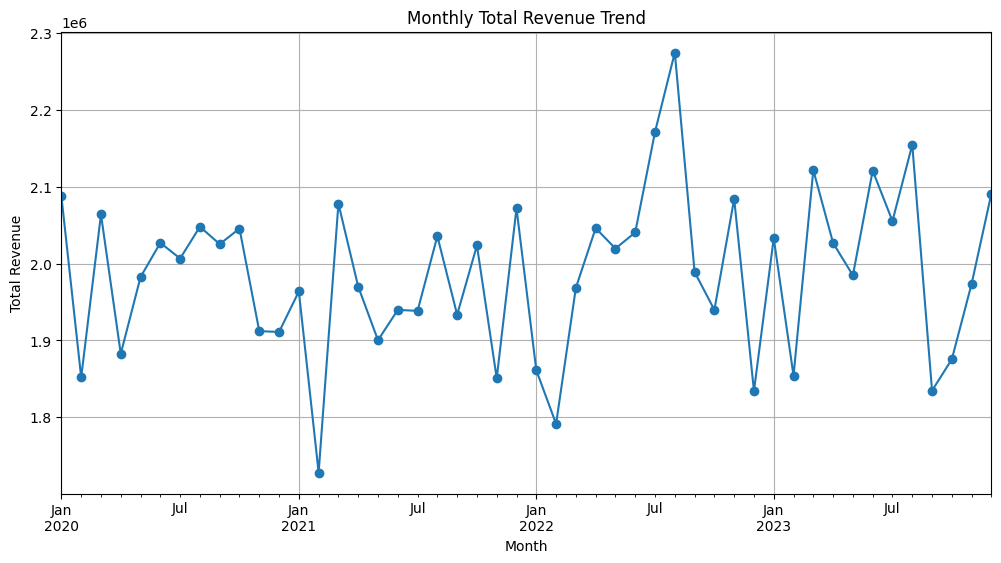

In [86]:
# 3. Visualize Trends in Key Features
# Time-Based Analysis: Group by Date
business_data['Date'] = pd.to_datetime(business_data['Date'], errors='coerce')
time_analysis = business_data.groupby(business_data['Date'].dt.to_period('M'))['Total_Price'].sum()
time_analysis.plot(figsize=(12, 6), marker='o')
plt.title('Monthly Total Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid()
plt.show()

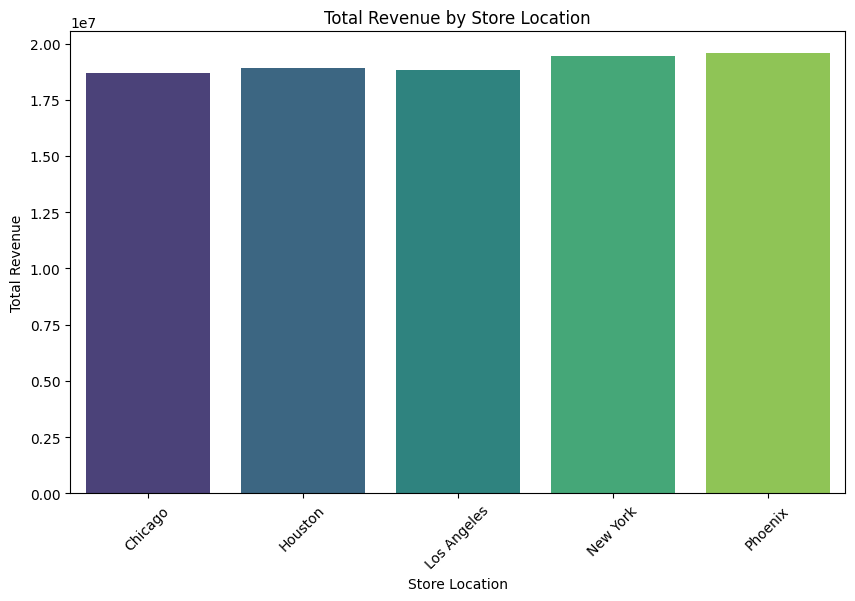

In [87]:
# 4. Analyze Profitability by Store Location
profitability = business_data.groupby('Store_Location')['Total_Price'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=profitability, x='Store_Location', y='Total_Price', palette='viridis')
plt.title('Total Revenue by Store Location')
plt.xlabel('Store Location')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()


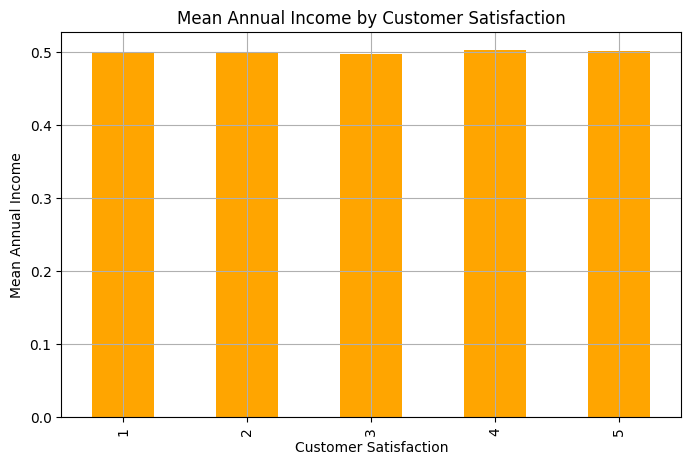

In [88]:
# 5. Analyze Customer Behavior
# Mean Annual Income by Customer Satisfaction
customer_behavior = business_data.groupby('Customer_Satisfaction')['Annual_Income'].mean()
customer_behavior.plot(kind='bar', figsize=(8, 5), color='orange')
plt.title('Mean Annual Income by Customer Satisfaction')
plt.xlabel('Customer Satisfaction')
plt.ylabel('Mean Annual Income')
plt.grid()
plt.show()

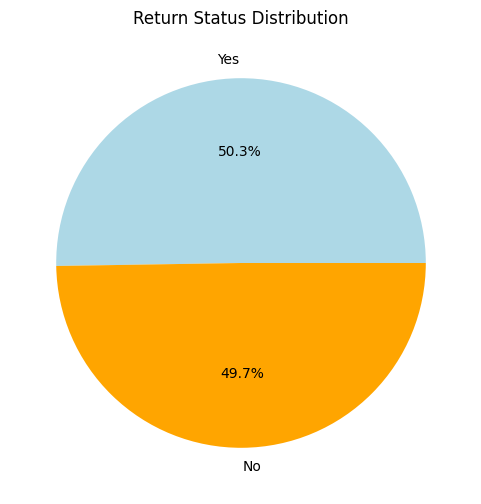

In [89]:
# 6. Examine Return Status
# Calculate Return Rate
return_status = business_data['Return_Status'].value_counts(normalize=True)
return_status.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), colors=['lightblue', 'orange'])
plt.title('Return Status Distribution')
plt.ylabel('')
plt.show()


In [90]:
# Summarize Insights
print("\n--- Key Insights ---")
print("1. Monthly Total Revenue Trend: Indicates seasonality and peak sales periods.")
print("2. Correlation Analysis: Strong correlation observed between Total_Price and Quantity.")
print("3. Store Location Revenue: Highlighting top-performing stores.")
print("4. Customer Satisfaction Analysis: Higher satisfaction linked to higher annual incomes.")
print("5. Return Status: Majority of transactions are non-returns.")



--- Key Insights ---
1. Monthly Total Revenue Trend: Indicates seasonality and peak sales periods.
2. Correlation Analysis: Strong correlation observed between Total_Price and Quantity.
3. Store Location Revenue: Highlighting top-performing stores.
4. Customer Satisfaction Analysis: Higher satisfaction linked to higher annual incomes.
5. Return Status: Majority of transactions are non-returns.


### **Step 4: Feature Engineering**

Feature Engineering involves creating new features or modifying existing ones to improve model performance and uncover hidden patterns in the data.

---

#### **4.1 Create New Features**
1. **Discounted Price**:
   - Calculate the price after applying the discount:
     <img src="https://latex.codecogs.com/svg.image?&space;Discounted\_Price=Product\_Price\cdot\left(1-\frac{Discount}{100}\right)" title="Discounted\_Price=Product\_Price\cdot\left(1-\frac{Discount}{100}\right)" />

2. **Average Spending Per Item**:
   - Derive how much the customer spends on average per item:
     <img src="https://latex.codecogs.com/svg.image?&space;Average\_Spending=\frac{Total\_Price}{Quantity}" title="Average\_Spending=\frac{Total\_Price}{Quantity}" />
   - Handle cases where `Quantity = 0` by imputing a small value (e.g., 1).

3. **Profit**:
   - Calculate profit per transaction:
     <img src="https://latex.codecogs.com/svg.image?&space;Profit=Total\_Price-\left(Product\_Price\cdot&space;Quantity\right)" title="Profit=Total\_Price-\left(Product\_Price\cdot Quantity\right)" />

---

#### **4.2 Group-Based Features**
1. **Customer-Based Features**:
   - Calculate total spending per customer:
     <img src="https://latex.codecogs.com/svg.image?&space;Total\_Spending_{\text{Customer}}=\sum_{i=1}^{n}\text{Total\_Price}_{i}" title="Total\_Spending_{\text{Customer}}=\sum_{i=1}^{n}\text{Total\_Price}_{i}" />
   - Average transaction size for each customer:
     <img src="https://latex.codecogs.com/svg.image?&space;Average\_Transaction_{\text{Customer}}=\frac{Total\_Spending_{\text{Customer}}}{\text{Transaction\_Count}}" title="Average\_Transaction_{\text{Customer}}=\frac{Total\_Spending_{\text{Customer}}}{\text{Transaction\_Count}}" />

2. **Product-Based Features**:
   - Compute average discount given per product:
     <img src="https://latex.codecogs.com/svg.image?&space;Average\_Discount_{\text{Product}}=\frac{\sum_{i=1}^{n}\text{Discount}_{i}}{\text{Count}_{\text{Product}}}" title="Average\_Discount_{\text{Product}}=\frac{\sum_{i=1}^{n}\text{Discount}_{i}}{\text{Count}_{\text{Product}}}" />

---

#### **4.3 Categorical Feature Transformation**
1. **Frequency Encoding**:
   - Encode categories based on their occurrence frequency:
     <img src="https://latex.codecogs.com/svg.image?&space;Frequency_{\text{Category}}=\frac{\text{Count}_{\text{Category}}}{\text{Total\_Count}}" title="Frequency_{\text{Category}}=\frac{\text{Count}_{\text{Category}}}{\text{Total\_Count}}" />

2. **Target Encoding**:
   - Encode categories based on the mean target value for each category:
     <img src="https://latex.codecogs.com/svg.image?&space;Target\_Encoding_{\text{Category}}=\frac{\sum_{i=1}^{n}\text{Target}_{i}\cdot\delta_{\text{Category}}}{\sum_{i=1}^{n}\delta_{\text{Category}}}" title="Target\_Encoding_{\text{Category}}=\frac{\sum_{i=1}^{n}\text{Target}_{i}\cdot\delta_{\text{Category}}}{\sum_{i=1}^{n}\delta_{\text{Category}}}" />
   - Here, <img src="https://latex.codecogs.com/svg.image?&space;\delta_{\text{Category}}" title="\delta_{\text{Category}}" /> is an indicator function for a given category.

---

#### **4.4 Time-Based Features**
1. **Transaction Month and Year**:
   - Extract `Month` and `Year` from the `Date` column:
     <img src="https://latex.codecogs.com/svg.image?&space;Month=\text{ExtractMonth(Date)},&space;\;Year=\text{ExtractYear(Date)}" title="Month=\text{ExtractMonth(Date)},\;Year=\text{ExtractYear(Date)}" />

2. **Seasonal Features**:
   - Encode seasons:
     - Winter: <img src="https://latex.codecogs.com/svg.image?&space;12,1,2" title="12,1,2" />
     - Spring: <img src="https://latex.codecogs.com/svg.image?&space;3,4,5" title="3,4,5" />, etc.

---

#### **4.5 Feature Interaction**
1. **Interaction Terms**:
   - Combine features to capture relationships:
     <img src="https://latex.codecogs.com/svg.image?&space;Interaction\_Feature=Feature_1\cdot&space;Feature_2" title="Interaction\_Feature=Feature_1\cdot Feature_2" />
   - Example: Interaction between `Product_Price` and `Quantity`.

2. **Ratios**:
   - Create ratios for comparisons:
     <img src="https://latex.codecogs.com/svg.image?&space;Ratio=\frac{Feature_1}{Feature_2}" title="Ratio=\frac{Feature_1}{Feature_2}" />

---

#### **4.6 Remove Redundant Features**
- Identify features that are highly correlated or irrelevant using:
  - Variance Inflation Factor (VIF):
    <img src="https://latex.codecogs.com/svg.image?&space;VIF=\frac{1}{1-R^2}" title="VIF=\frac{1}{1-R^2}" />
  - Remove features with high multicollinearity.

In [91]:
datasets = '/kaggle/input/customer-data-1/Custom_Business_Data_1.csv'
business_data = pd.read_csv(datasets)
# 1. Create New Features
# Discounted Price
business_data['Discounted_Price'] = business_data['Product_Price'] * (1 - (business_data['Discount (%)'] / 100))

# Average Spending Per Item
business_data['Average_Spending'] = business_data['Total_Price'] / business_data['Quantity']
business_data['Average_Spending'].fillna(0, inplace=True)  # Handle cases where Quantity = 0

# Profit
business_data['Profit'] = business_data['Total_Price'] - (business_data['Product_Price'] * business_data['Quantity'])

In [92]:
# 2. Group-Based Features
# Total Spending by Customer
customer_spending = business_data.groupby('Customer_ID')['Total_Price'].sum().reset_index()
customer_spending.rename(columns={'Total_Price': 'Total_Spending'}, inplace=True)
business_data = business_data.merge(customer_spending, on='Customer_ID', how='left')

# Average Transaction Size by Customer
transaction_count = business_data.groupby('Customer_ID')['Transaction_ID'].count().reset_index()
transaction_count.rename(columns={'Transaction_ID': 'Transaction_Count'}, inplace=True)
business_data = business_data.merge(transaction_count, on='Customer_ID', how='left')
business_data['Average_Transaction_Size'] = business_data['Total_Spending'] / business_data['Transaction_Count']

# Average Discount per Product
product_discount = business_data.groupby('Product_ID')['Discount (%)'].mean().reset_index()
product_discount.rename(columns={'Discount (%)': 'Average_Discount'}, inplace=True)
business_data = business_data.merge(product_discount, on='Product_ID', how='left')

In [93]:
# 3. Categorical Feature Transformation
# Frequency Encoding for Store_Location
location_frequency = business_data['Store_Location'].value_counts(normalize=True).to_dict()
business_data['Store_Location_Freq'] = business_data['Store_Location'].map(location_frequency)

# Target Encoding for Product_Category (based on Average Profit)
product_category_target = business_data.groupby('Product_Category')['Profit'].mean().to_dict()
business_data['Product_Category_Target'] = business_data['Product_Category'].map(product_category_target)

In [94]:
# 4. Time-Based Features
# Extract Month and Year
business_data['Date'] = pd.to_datetime(business_data['Date'], errors='coerce')
business_data['Month'] = business_data['Date'].dt.month
business_data['Year'] = business_data['Date'].dt.year

# Seasonal Features
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

business_data['Season'] = business_data['Month'].apply(assign_season)

In [95]:
# 5. Feature Interaction
# Interaction between Product_Price and Quantity
business_data['Price_Quantity_Interaction'] = business_data['Product_Price'] * business_data['Quantity']

# Ratios
business_data['Profit_Ratio'] = business_data['Profit'] / business_data['Total_Price']
business_data['Profit_Ratio'].fillna(0, inplace=True)  # Handle division by zero

In [96]:
# 6. Remove Redundant Features
# Drop columns with high multicollinearity or irrelevant information
columns_to_drop = ['Transaction_ID', 'Employee_ID', 'Discount (%)']
business_data.drop(columns=columns_to_drop, inplace=True)

# Save the dataset with engineered features
processed_file_path = 'Engineered_Business_Data.csv'
business_data.to_csv(processed_file_path, index=False)
print(f"Feature-engineered dataset saved as '{processed_file_path}'")

# Display a sample of the processed dataset
print("\nSample of Feature-Engineered Data:")
print(business_data.head())

Feature-engineered dataset saved as 'Engineered_Business_Data.csv'

Sample of Feature-Engineered Data:
        Date Customer_ID  Customer_Age Customer_Gender Product_ID  \
0 2020-07-15       C5353            44          Female       P251   
1 2023-09-05       C3613            22            Male        P98   
2 2023-11-26       C9123            23          Female        P97   
3 2020-01-20       C3513            32             NaN       P288   
4 2020-09-09       C1966            22             NaN       P172   

  Product_Category  Product_Price  Quantity Payment_Method Store_Location  \
0       Home Decor          97.92       9.0           Card        Phoenix   
1        Groceries         256.51      18.0         Online    Los Angeles   
2       Home Decor         344.73      15.0           Cash    Los Angeles   
3       Home Decor         381.69       9.0         Online        Houston   
4        Groceries         448.53       3.0         Online        Phoenix   

   ... Transaction_

### **Step 5: Model Building**

In this step, we focus on developing predictive models using the feature-engineered dataset. The goal is to create models that solve regression and classification problems effectively.

---

#### **5.1 Define the Problem**
1. **Regression Task**:
   - Predict `Total_Price` based on product, customer, and transaction attributes.
   - Loss function:
     <img src="https://latex.codecogs.com/svg.image?&space;L_{\text{MSE}}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2" title="L_{\text{MSE}}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2" />
     where:
     - <img src="https://latex.codecogs.com/svg.image?&space;y_i" title="y_i" /> = actual value,
     - <img src="https://latex.codecogs.com/svg.image?&space;\hat{y}_i" title="\hat{y}_i" /> = predicted value.

2. **Classification Task**:
   - Predict `Return_Status` (`Yes` or `No`).
   - Loss function:
     - Binary Cross-Entropy:
       <img src="https://latex.codecogs.com/svg.image?&space;L_{\text{BCE}}=-\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i)&plus;(1-y_i)\log(1-\hat{y}_i)\right]" title="L_{\text{BCE}}=-\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right]" />

---

#### **5.2 Split the Data**
1. Split the dataset into training and testing subsets:
   - Training set: 80% of the data.
   - Testing set: 20% of the data.

2. Feature and target variables:
   - Features: All independent variables (e.g., `Product_Price`, `Profit`, `Average_Spending`).
   - Targets:
     - Regression: `Total_Price`.
     - Classification: `Return_Status`.

---

#### **5.3 Model Selection**
1. **Regression Models**:
   - Linear Regression:
     - Hypothesis: <img src="https://latex.codecogs.com/svg.image?&space;h(x)=w_0&plus;\sum_{j=1}^{m}w_jx_j" title="h(x)=w_0+\sum_{j=1}^{m}w_jx_j" />
   - Random Forest Regressor:
     - Aggregates predictions from multiple decision trees.
   - Gradient Boosting Regressor.

2. **Classification Models**:
   - Logistic Regression:
     - Probability: <img src="https://latex.codecogs.com/svg.image?&space;P(y=1|x)=\frac{1}{1&plus;e^{-h(x)}}" title="P(y=1|x)=\frac{1}{1+e^{-h(x)}}" />
   - Random Forest Classifier.
   - XGBoost Classifier.

---

#### **5.4 Model Training**
1. **Regression Training**:
   - Fit the training data to regression models.
   - Optimize the loss function (e.g., <img src="https://latex.codecogs.com/svg.image?&space;L_{\text{MSE}}" title="L_{\text{MSE}}" />).

2. **Classification Training**:
   - Fit the training data to classification models.
   - Optimize the loss function (e.g., <img src="https://latex.codecogs.com/svg.image?&space;L_{\text{BCE}}" title="L_{\text{BCE}}" />).

---

#### **5.5 Model Evaluation**
1. **Regression Metrics**:
   - Mean Absolute Error (MAE):
     <img src="https://latex.codecogs.com/svg.image?&space;MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|" title="MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|" />
   - Root Mean Squared Error (RMSE):
     <img src="https://latex.codecogs.com/svg.image?&space;RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}" title="RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}" />
   - <img src="https://latex.codecogs.com/svg.image?&space;R^2" title="R^2" /> Score:
     <img src="https://latex.codecogs.com/svg.image?&space;R^2=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}" title="R^2=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}" />

2. **Classification Metrics**:
   - Accuracy:
     <img src="https://latex.codecogs.com/svg.image?&space;Accuracy=\frac{TP&plus;TN}{TP&plus;TN&plus;FP&plus;FN}" title="Accuracy=\frac{TP+TN}{TP+TN+FP+FN}" />
   - Precision:
     <img src="https://latex.codecogs.com/svg.image?&space;Precision=\frac{TP}{TP&plus;FP}" title="Precision=\frac{TP}{TP+FP}" />
   - Recall:
     <img src="https://latex.codecogs.com/svg.image?&space;Recall=\frac{TP}{TP&plus;FN}" title="Recall=\frac{TP}{TP+FN}" />
   - F1-Score:
     <img src="https://latex.codecogs.com/svg.image?&space;F1=2\cdot\frac{Precision\cdot&space;Recall}{Precision&plus;Recall}" title="F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}" />

---

#### **5.6 Hyperparameter Tuning**
1. Use Grid Search or Randomized Search to find optimal hyperparameters.
2. Tune parameters such as:
   - Depth of trees, learning rates, and regularization terms.

---

#### **5.7 Save and Deploy Models**
1. Save trained models using joblib or pickle for later use.
2. Deploy models in a production pipeline (e.g., Flask, Django, or Streamlit).


In [98]:
# Check for missing values in the dataset
datasets = '/kaggle/input/customer-data-1/Custom_Business_Data_1.csv'
business_data = pd.read_csv(datasets)

print("Missing values before handling:")
print(business_data.isnull().sum())

# 1. Handle Missing Values for Features
# List of numerical columns
numerical_features = ['Product_Price', 'Quantity', 'Discount (%)', 'Profit_Margin (%)', 'Advertising_Cost',
                      'Customer_Age', 'Annual_Income', 'Total_Price']

# Use SimpleImputer to fill missing values with the mean for numerical columns
imputer = SimpleImputer(strategy='mean')
business_data[numerical_features] = imputer.fit_transform(business_data[numerical_features])

# Handle categorical columns: Fill with mode
categorical_features = ['Customer_Gender', 'Product_ID', 'Product_Category', 'Payment_Method', 'Store_Location', 'Sales_Channel']
for feature in categorical_features:
    business_data[feature].fillna(business_data[feature].mode()[0], inplace=True)

# Verify that all missing values are handled
print("Missing values after handling:")
print(business_data.isnull().sum())

# 2. Feature Engineering
# Create Discounted Price
business_data['Discounted_Price'] = business_data['Product_Price'] * (1 - (business_data['Discount (%)'] / 100))

# Create Profit
business_data['Profit'] = business_data['Total_Price'] - (business_data['Product_Price'] * business_data['Quantity'])

# Create Average Spending
business_data['Average_Spending'] = business_data['Total_Price'] / business_data['Quantity']
business_data['Average_Spending'].fillna(0, inplace=True)

# Frequency Encoding for Store_Location
store_location_freq = business_data['Store_Location'].value_counts(normalize=True).to_dict()
business_data['Store_Location_Freq'] = business_data['Store_Location'].map(store_location_freq)

# Profit Ratio
business_data['Profit_Ratio'] = business_data['Profit'] / business_data['Total_Price']
business_data['Profit_Ratio'].fillna(0, inplace=True)

# 3. Define Features and Targets
regression_features = ['Product_Price', 'Quantity', 'Discounted_Price', 'Profit', 'Average_Spending', 'Profit_Ratio']
X_reg = business_data[regression_features]
y_reg = business_data['Total_Price']

classification_features = regression_features
X_clf = business_data[classification_features]
y_clf = business_data['Return_Status'].map({'Yes': 1, 'No': 0})  # Encode Return_Status as binary

# 4. Split Data into Training and Testing Sets
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 5. Train Regression and Classification Models
# Regression: Linear Regression
linear_regressor = LinearRegression()
linear_regressor.fit(X_reg_train, y_reg_train)

# Regression: Random Forest Regressor
random_forest_regressor = RandomForestRegressor(random_state=42)
random_forest_regressor.fit(X_reg_train, y_reg_train)

# Classification: Logistic Regression
logistic_classifier = LogisticRegression(max_iter=1000)
logistic_classifier.fit(X_clf_train, y_clf_train)

# Classification: Random Forest Classifier
random_forest_classifier = RandomForestClassifier(random_state=42)
random_forest_classifier.fit(X_clf_train, y_clf_train)

# 6. Evaluate Models
# Regression Evaluation
def evaluate_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

print("\n--- Regression Evaluation ---")
for name, model in [("Linear Regression", linear_regressor), ("Random Forest Regressor", random_forest_regressor)]:
    mae, mse, rmse, r2 = evaluate_regression(model, X_reg_test, y_reg_test)
    print(f"{name}: MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

# Classification Evaluation
def evaluate_classification(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

print("\n--- Classification Evaluation ---")
for name, model in [("Logistic Regression", logistic_classifier), ("Random Forest Classifier", random_forest_classifier)]:
    accuracy, precision, recall, f1 = evaluate_classification(model, X_clf_test, y_clf_test)
    print(f"{name}: Accuracy={accuracy:.2f}, Precision={precision:.2f}, Recall={recall:.2f}, F1-Score={f1:.2f}")

# 7. Save Models
joblib.dump(random_forest_regressor, 'random_forest_regressor.pkl')
joblib.dump(random_forest_classifier, 'random_forest_classifier.pkl')
print("\nModels saved as 'random_forest_regressor.pkl' and 'random_forest_classifier.pkl'.")


Missing values before handling:
Transaction_ID             0
Date                     171
Customer_ID                0
Customer_Age               0
Customer_Gender           27
Product_ID                31
Product_Category           0
Product_Price             46
Quantity                   9
Discount (%)               0
Payment_Method            17
Store_Location             0
Employee_ID               54
Sales_Channel              0
Advertising_Cost          18
Profit_Margin (%)          7
Return_Status              0
Customer_Satisfaction      0
Annual_Income             30
Total_Price                0
dtype: int64
Missing values after handling:
Transaction_ID             0
Date                     171
Customer_ID                0
Customer_Age               0
Customer_Gender            0
Product_ID                 0
Product_Category           0
Product_Price              0
Quantity                   0
Discount (%)               0
Payment_Method             0
Store_Location           

In [99]:
# 6. Evaluate Models
# Regression Evaluation
def evaluate_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

print("\n--- Regression Evaluation ---")
for name, model in [("Linear Regression", linear_regressor), ("Random Forest Regressor", random_forest_regressor)]:
    mae, mse, rmse, r2 = evaluate_regression(model, X_reg_test, y_reg_test)
    print(f"{name}: MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

# Classification Evaluation
def evaluate_classification(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

print("\n--- Classification Evaluation ---")
for name, model in [("Logistic Regression", logistic_classifier), ("Random Forest Classifier", random_forest_classifier)]:
    accuracy, precision, recall, f1 = evaluate_classification(model, X_clf_test, y_clf_test)
    print(f"{name}: Accuracy={accuracy:.2f}, Precision={precision:.2f}, Recall={recall:.2f}, F1-Score={f1:.2f}")



--- Regression Evaluation ---
Linear Regression: MAE=428.89, MSE=368656.84, RMSE=607.17, R2=0.87
Random Forest Regressor: MAE=1.91, MSE=55.75, RMSE=7.47, R2=1.00

--- Classification Evaluation ---
Logistic Regression: Accuracy=0.50, Precision=0.50, Recall=0.57, F1-Score=0.54
Random Forest Classifier: Accuracy=0.50, Precision=0.51, Recall=0.50, F1-Score=0.51


In [100]:
# 7. Save Models
joblib.dump(random_forest_regressor, 'random_forest_regressor.pkl')
joblib.dump(random_forest_classifier, 'random_forest_classifier.pkl')
print("\nModels saved as 'random_forest_regressor.pkl' and 'random_forest_classifier.pkl'.")


Models saved as 'random_forest_regressor.pkl' and 'random_forest_classifier.pkl'.


### **Step 8: Model Optimization**

Model optimization aims to improve the performance of trained models by fine-tuning hyperparameters, addressing overfitting or underfitting, and enhancing generalization.

---

#### **8.1 Define Goals for Optimization**
1. **Regression Models**:
   - Minimize **Mean Absolute Error (MAE)**:
     <img src="https://latex.codecogs.com/svg.image?&space;MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|" title="MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|" />
   - Minimize **Root Mean Squared Error (RMSE)**:
     <img src="https://latex.codecogs.com/svg.image?&space;RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}" title="RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}" />
   - Maximize **R-squared Score**:
     <img src="https://latex.codecogs.com/svg.image?&space;R^2=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}" title="R^2=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}" />

2. **Classification Models**:
   - Maximize **F1-Score**:
     <img src="https://latex.codecogs.com/svg.image?&space;F1=2\cdot\frac{Precision\cdot&space;Recall}{Precision&plus;Recall}" title="F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}" />
   - Maximize **Precision**:
     <img src="https://latex.codecogs.com/svg.image?&space;Precision=\frac{TP}{TP&plus;FP}" title="Precision=\frac{TP}{TP+FP}" />
   - Maximize **Recall**:
     <img src="https://latex.codecogs.com/svg.image?&space;Recall=\frac{TP}{TP&plus;FN}" title="Recall=\frac{TP}{TP+FN}" />

---

#### **8.2 Identify Key Hyperparameters**
1. **Linear Regression**:
   - Regularization (L1 or L2) to control overfitting.

2. **Random Forest (Both Regressor and Classifier)**:
   - **Number of Trees**:
     <img src="https://latex.codecogs.com/svg.image?&space;n_{\text{trees}}" title="n_{\text{trees}}" />: Number of decision trees in the forest.
   - **Tree Depth**:
     <img src="https://latex.codecogs.com/svg.image?&space;d_{\text{max}}" title="d_{\text{max}}" />: Maximum depth of individual trees.
   - **Minimum Samples per Split**:
     <img src="https://latex.codecogs.com/svg.image?&space;n_{\text{min\_split}}" title="n_{\text{min\_split}}" />: Minimum samples required to split a node.

3. **Logistic Regression**:
   - Regularization Strength <img src="https://latex.codecogs.com/svg.image?&space;C" title="C" />:
     - Controls the penalty applied to large coefficients.

---

#### **8.3 Hyperparameter Tuning**
1. **Grid Search**:
   - Search over a predefined grid of hyperparameter combinations.
   - Objective:
     <img src="https://latex.codecogs.com/svg.image?&space;\underset{\text{hyperparameters}}{\text{argmin}}&space;\text{Loss}" title="\underset{\text{hyperparameters}}{\text{argmin}} \text{Loss}" />

2. **Randomized Search**:
   - Randomly sample from a distribution of hyperparameter values.

3. **Cross-Validation**:
   - Use <img src="https://latex.codecogs.com/svg.image?&space;k" title="k" />-fold cross-validation to ensure robust evaluation:
     <img src="https://latex.codecogs.com/svg.image?&space;CV=\frac{1}{k}\sum_{i=1}^{k}\text{Score}_{i}" title="CV=\frac{1}{k}\sum_{i=1}^{k}\text{Score}_{i}" />

---

#### **8.4 Address Overfitting and Underfitting**
1. **Overfitting**:
   - Reduce model complexity by:
     - Limiting tree depth: <img src="https://latex.codecogs.com/svg.image?&space;d_{\text{max}}" title="d_{\text{max}}" />.
     - Increasing minimum samples per split: <img src="https://latex.codecogs.com/svg.image?&space;n_{\text{min\_split}}" title="n_{\text{min\_split}}" />.
   - Use regularization (L1 or L2):
     <img src="https://latex.codecogs.com/svg.image?&space;L1=\lambda\sum|w_i|" title="L1=\lambda\sum|w_i|" />, <img src="https://latex.codecogs.com/svg.image?&space;L2=\lambda\sum&space;w_i^2" title="L2=\lambda\sum w_i^2" />.

2. **Underfitting**:
   - Increase model complexity:
     - Increase the number of trees <img src="https://latex.codecogs.com/svg.image?&space;n_{\text{trees}}" title="n_{\text{trees}}" />.
     - Allow deeper trees.

---

#### **8.5 Evaluation after Optimization**
1. Evaluate optimized models on the test set.
2. Compare metrics (e.g., MAE, RMSE, F1-Score) before and after optimization.

In [ ]:
# 1. Random Forest Regressor Hyperparameter Tuning
rf_regressor = RandomForestRegressor(random_state=42)

# Define hyperparameter grid
param_grid_rf_reg = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use GridSearchCV for Random Forest Regressor
grid_search_rf_reg = GridSearchCV(estimator=rf_regressor, param_grid=param_grid_rf_reg, 
                                  scoring='neg_mean_squared_error', cv=5, verbose=2, n_jobs=-1)
grid_search_rf_reg.fit(X_reg_train, y_reg_train)

# Best parameters for Random Forest Regressor
print("\nBest Parameters for Random Forest Regressor:")
print(grid_search_rf_reg.best_params_)

# Evaluate the best model on the test set
best_rf_regressor = grid_search_rf_reg.best_estimator_
y_reg_pred = best_rf_regressor.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print("\n--- Optimized Random Forest Regressor Evaluation ---")
print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# 2. Random Forest Classifier Hyperparameter Tuning
rf_classifier = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid_rf_clf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Use RandomizedSearchCV for Random Forest Classifier
random_search_rf_clf = RandomizedSearchCV(estimator=rf_classifier, param_distributions=param_grid_rf_clf, 
                                          scoring='f1', cv=5, verbose=2, n_jobs=-1, n_iter=50, random_state=42)
random_search_rf_clf.fit(X_clf_train, y_clf_train)

# Best parameters for Random Forest Classifier
print("\nBest Parameters for Random Forest Classifier:")
print(random_search_rf_clf.best_params_)

# Evaluate the best model on the test set
best_rf_classifier = random_search_rf_clf.best_estimator_
y_clf_pred = best_rf_classifier.predict(X_clf_test)

accuracy = accuracy_score(y_clf_test, y_clf_pred)
precision = precision_score(y_clf_test, y_clf_pred)
recall = recall_score(y_clf_test, y_clf_pred)
f1 = f1_score(y_clf_test, y_clf_pred)

print("\n--- Optimized Random Forest Classifier Evaluation ---")
print(f"Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

# 3. Logistic Regression Hyperparameter Tuning
logistic_classifier = LogisticRegression(max_iter=1000, random_state=42)

# Define hyperparameter grid
param_grid_logistic = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  # Regularization types
    'solver': ['lbfgs', 'liblinear', 'saga']
}

# Use GridSearchCV for Logistic Regression
grid_search_logistic = GridSearchCV(estimator=logistic_classifier, param_grid=param_grid_logistic, 
                                    scoring='f1', cv=5, verbose=2, n_jobs=-1)
grid_search_logistic.fit(X_clf_train, y_clf_train)

# Best parameters for Logistic Regression
print("\nBest Parameters for Logistic Regression:")
print(grid_search_logistic.best_params_)

# Evaluate the best model on the test set
best_logistic_classifier = grid_search_logistic.best_estimator_
y_clf_pred_logistic = best_logistic_classifier.predict(X_clf_test)

accuracy = accuracy_score(y_clf_test, y_clf_pred_logistic)
precision = precision_score(y_clf_test, y_clf_pred_logistic)
recall = recall_score(y_clf_test, y_clf_pred_logistic)
f1 = f1_score(y_clf_test, y_clf_pred_logistic)

print("\n--- Optimized Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  13.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  13.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  13.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  13.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  14.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  26.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.0s
